# Homework 9

## Problem 1 (25 points):
Use the three methods from the lecture and calculate the roots of the following functions (always plot the graphs):
1. $log(x) - exp(-5)$ 
2. $x^3 - 7x^2 + 14x -8$
3. $log(x) \times exp(-x)$ 

Please use lambda function and **don't use for or while loops**



## Problem 2 (25 points):
You have a 4x4 2D array with two missing values (NaNs).
 Use linear interpolation to fill in the missing values. 
 Use numpy and scipy.interpolate.griddata (or another suitable method) 
 to complete the task.
 

In [ ]:
from scipy import interpolate
import numpy as np

data = np.array([
    [1, 2, 3, 4],
    [5, 6, np.NaN, 8],
    [9, 10, 11, 12],
    [13, np.NaN, 15, 16]
])


In [4]:
import numpy as np
from scipy import interpolate

# Original 4x4 data with two NaN values
data = np.array([
    [1, 2, 3, 4],
    [5, 6, np.nan, 8],
    [9, 10, 11, 12],
    [13, np.nan, 15, 16]
])

# Step 1: Create meshgrid of indices for the 2D array
x, y = np.indices(data.shape)

# Step 2:  Get known data (not nan)
valid_mask = ~np.isnan(data)  # Mask to find valid data points
valid_x = x[valid_mask]
valid_y = y[valid_mask]
valid_data = data[valid_mask]

# Step 3: Get unknown data points 
nan_mask = np.isnan(data)
nan_x = x[nan_mask]
nan_y = y[nan_mask]

# Step 4: Perform griddata interpolation to fill NaNs
filled_values = interpolate.griddata(
    (valid_x, valid_y),  # Points with valid data
    valid_data,          # The corresponding valid data
    (nan_x, nan_y),      # Points where we have NaNs
    method='linear'      # Use linear interpolation
)

# Step 5: replace the nan values with the interpolated data 
data[nan_mask] = filled_values

# Display the updated data
print("Data after interpolation:")
print(data)

Data after interpolation:
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]


## Problem 3 (30 points)

As a bioenegener or biocoputational enegener you are provided with an image, `HeadCT.png`, which contains some bad pixels that appear as ring artifacts that is commonly seen in CT images. Your task is to use Python libraries like `numpy` and `scipy` (specifically, `scipy.interpolate.griddata` to correct these bad pixels.

### Requirements:
1. **Identify the bad pixels**: Detect the regions where the pixel values are significantly different from surrounding pixels or follow a pattern indicative of the vertical stripes.
2. **Apply Interpolation**: Use `scipy.interpolate.griddata` to estimate values for these bad pixels based on the surrounding good pixels.
3. **Output**: Return the corrected image data or display the corrected image to verify the interpolation quality visually.


Type: <class 'numpy.ndarray'>
Shape: (880, 770)
Data type: uint8


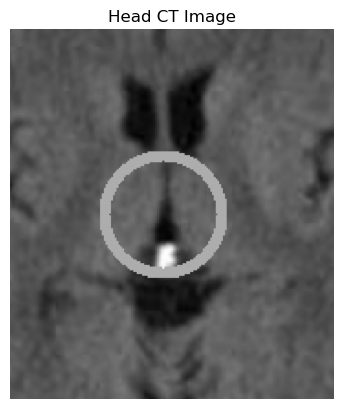

In [3]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ---- Load and convert to numpy array ----
image_path = 'HeadCT.png'

img = Image.open(image_path).convert('L')   # convert to grayscale
img_np = np.array(img)                      # to numpy array

# ---- Print basic info ----
print("Type:", type(img_np))
print("Shape:", img_np.shape)
print("Data type:", img_np.dtype)

# ---- Plot the image ----
plt.imshow(img_np, cmap='gray')
plt.title("Head CT Image")
plt.axis('off')
plt.show()


In [5]:
pwd

'C:\\Users\\Bahaa\\OneDrive\\Desktop\\umd\\2025\\BIOE 658 Fall 2024 python\\hw 7 numerical analysis'

Type: <class 'numpy.ndarray'>
Shape: (880, 770)
Data type: uint8


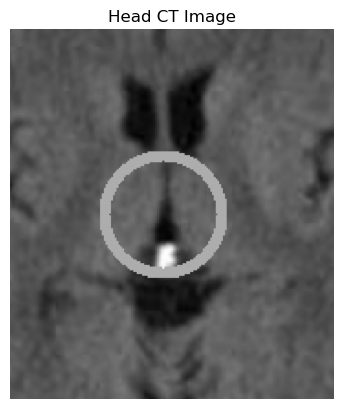

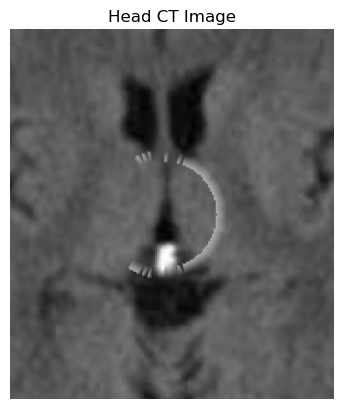

In [6]:
# -*- coding: utf-8 -*-
"""
Created on Mon Dec  1 09:12:38 2025

@author: Bahaa
"""

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ---- Load and convert to numpy array ----
image_path = 'HeadCT.png'

img = Image.open(image_path).convert('L')   # convert to grayscale
img_np = np.array(img)                      # to numpy array

# ---- Print basic info ----
print("Type:", type(img_np))
print("Shape:", img_np.shape)
print("Data type:", img_np.dtype)

# ---- Plot the image ----
plt.imshow(img_np, cmap='gray')
plt.title("Head CT Image")
plt.axis('off')
plt.show()

#%%
import numpy as np
from scipy import interpolate



# Step 1: Create meshgrid of indices for the 2D array
x, y = np.indices(img_np.shape)

# Step 2:  Get known data (not nan)
valid_mask = img_np!=173  # Mask to find valid data points
valid_x = x[valid_mask]
valid_y = y[valid_mask]
valid_data = img_np[valid_mask]

# Step 3: Get unknown data points 
nan_mask = img_np==173
nan_x = x[nan_mask]
nan_y = y[nan_mask]

# Step 4: Perform griddata interpolation to fill NaNs
filled_values = interpolate.griddata(
    (valid_x, valid_y),  # Points with valid data
    valid_data,          # The corresponding valid data
    (nan_x, nan_y),      # Points where we have NaNs
    method='linear'      # Use linear interpolation
)

# Step 5: replace the nan values with the interpolated data 
img_np[nan_mask] = filled_values

#%% ---- Plot the image ----
plt.imshow(img_np, cmap='gray')
plt.title("Head CT Image")
plt.axis('off')
plt.show()